# Generate data, lesioning postsynaptic connections of inhibitory neurons

date: 6/29/26
this is a test case just to make sure that the lesioning is working properly

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-06-29 22:23:38.362764: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 22:23:38.372019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-29 22:23:38.381220: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-29 22:23:38.384578: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-29 22:23:38.393091: I tensorflow/core/platform/cpu_feature_guar

## delay=150, lesion inhibitory

In [2]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

### necessary functions

In [3]:
from itertools import permutations
import random
from collections import Counter

def generate_sternberg_trialtypes_load3(stimuli, memory_set_size=3, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a Sternberg block balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations, not combinations)
      - Serial position of match probe (each position probed once per sequence)
      - Stimulus identity as match and mismatch probe
    
    Block size: 2 * P(n,k) * k = 2 * 24 * 3 = 144 trials (for 4 stimuli, set size 3)
    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                           match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))
    trial_type_all = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]
            assert len(excluded) == 1
            mismatch_probe = excluded[0]

            for pos in range(memory_set_size):
                trial_type_all.append([memory_set_size,  1] + seq + [seq[pos]])        # match
                trial_type_all.append([memory_set_size, -1] + seq + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trial_type_all)

    return np.array(trial_type_all)  # shape: (n_trials, 6)

In [4]:
def generate_sternberg_trialtypes_load1(stimuli, memory_set_size=1, shuffle=False, n_repeats=1, seed=None):
    """
    Generate a load-1 Sternberg block with all possible trial combinations, balanced on:
      - Match vs mismatch (50/50)
      - All ordered memory sequences (permutations of size 1)
      - All possible mismatch probes for each sequence

    For load 1: 
      - 4 unique match trials (each stimulus shown and probed once)
      - 12 unique mismatch trials (4 sequences x 3 excluded stimuli)
      - Each match trial repeated 3x to achieve 50/50 balance
      - Total: 24 trials per repeat

    Output shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]
                                            stim2, stim3 = NaN (unused at load 1)
                                            match: 1 = match, -1 = mismatch
    """
    if seed is not None:
        random.seed(seed)

    seqs = list(permutations(stimuli, memory_set_size))  # 4 single-element sequences
    trials = []

    for _ in range(n_repeats):
        for seq in seqs:
            seq = list(seq)
            excluded = [x for x in stimuli if x not in seq]  # 3 excluded stimuli

            # All 3 mismatch probes for this sequence
            for mismatch_probe in excluded:
                trials.append([memory_set_size,  1] + seq + [float('nan'), float('nan')] + [seq[0]])          # match (repeated 3x across excluded loop)
                trials.append([memory_set_size, -1] + seq + [float('nan'), float('nan')] + [mismatch_probe])  # mismatch

    if shuffle:
        random.shuffle(trials)

    return np.array(trials, dtype=float)  # shape: (n_trials, 6)

In [5]:
def generate_u_from_trialtypes(trial_type_all, settings):
    """
    Generate input u from trial_type_all.
    """
    n_trials = trial_type_all.shape[0]
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    
    n_channels = 4
    u_all = np.zeros((n_trials, n_channels, settings["T"]), dtype=np.float32)  # shape: (n_trials, T, n_channels)
    
    for i_trial in range(n_trials):
        u = np.zeros((n_channels, t_total), dtype=np.float32)
        stim_chan_idx = trial_type_all[i_trial, 2:-1] # stim channels are in columns 2 to -1 (excluding last column which is probe)
        stim_chan_idx = stim_chan_idx[~np.isnan(stim_chan_idx)].astype(int) # remove possible nan's from stim_chan_idx (in case of lower load)
        probe_chan_idx = trial_type_all[i_trial, -1].astype(int)
        
        for i, i_chan in enumerate(stim_chan_idx):
            if i == 0:
                u[i_chan, stim_on:stim_on+stim_dur] = 1
                ending_idx = stim_on+stim_dur
            else: # 0 bc no separation btwn stimuli
                u[i_chan, ending_idx+0:ending_idx+stim_dur+0] = 1
                ending_idx = ending_idx+stim_dur+0
        
        u[probe_chan_idx, ending_idx+delay:ending_idx+delay+stim_dur] = 1
        u_all[i_trial] = u

    return u_all

#### checks

In [17]:
# a check - for load3
from collections import Counter

# --- Run it ---
stimuli = [0, 1, 2, 3]
memory_set_size = 3

trial_type_all = generate_sternberg_trialtypes_load3(stimuli, shuffle=False, n_repeats=3, seed=42)
# block shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]

# Derive match/mismatch: probe is in the memory set
is_match = np.array([trial_type_all[i, 5] in trial_type_all[i, 2:5] for i in range(len(trial_type_all))])

print(f"Total trials: {len(trial_type_all)}\n")
for i in range(min(12, len(trial_type_all))):
    mem = trial_type_all[i, 2:5].tolist()
    probe = trial_type_all[i, 5]
    trial_type = "match" if is_match[i] else "mismatch"
    print(f"Trial {i+1:3d}: Memory={mem}  Probe={probe}  ({trial_type})")
print(f"  ... ({len(trial_type_all) - 12} more trials)")

# --- Balance checks ---
match_trials    = trial_type_all[is_match]
mismatch_trials = trial_type_all[~is_match]

print(f"\n--- Balance Check ---")
print(f"Match trials:    {len(match_trials)}")
print(f"Mismatch trials: {len(mismatch_trials)}")

print(f"\nMatch probe identity:    {Counter(match_trials[:, 5].tolist())}")
print(f"Mismatch probe identity: {Counter(mismatch_trials[:, 5].tolist())}")

print(f"\nMatch probe by serial position:")
for pos in range(memory_set_size):
    at_pos = match_trials[match_trials[:, pos] == match_trials[:, 5]]
    print(f"  Position {pos}: {Counter(at_pos[:, 5].tolist())}")

print(f"\nUnique ordered memory sequences (match):    "
      f"{len(set(map(tuple, match_trials[:, 2:5].tolist())))}")
print(f"Unique ordered memory sequences (mismatch): "
      f"{len(set(map(tuple, mismatch_trials[:, 2:5].tolist())))}")

Total trials: 432

Trial   1: Memory=[0, 1, 2]  Probe=0  (match)
Trial   2: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   3: Memory=[0, 1, 2]  Probe=1  (match)
Trial   4: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   5: Memory=[0, 1, 2]  Probe=2  (match)
Trial   6: Memory=[0, 1, 2]  Probe=3  (mismatch)
Trial   7: Memory=[0, 1, 3]  Probe=0  (match)
Trial   8: Memory=[0, 1, 3]  Probe=2  (mismatch)
Trial   9: Memory=[0, 1, 3]  Probe=1  (match)
Trial  10: Memory=[0, 1, 3]  Probe=2  (mismatch)
Trial  11: Memory=[0, 1, 3]  Probe=3  (match)
Trial  12: Memory=[0, 1, 3]  Probe=2  (mismatch)
  ... (420 more trials)

--- Balance Check ---
Match trials:    216
Mismatch trials: 216

Match probe identity:    Counter({0: 54, 1: 54, 2: 54, 3: 54})
Mismatch probe identity: Counter({3: 54, 2: 54, 1: 54, 0: 54})

Match probe by serial position:
  Position 0: Counter({3: 54})
  Position 1: Counter({1: 54})
  Position 2: Counter({0: 18, 1: 18, 2: 18, 3: 18})

Unique ordered memory sequences (match):    24


In [18]:
trial_type_all.shape

(432, 6)

In [27]:
# a check - for load1
from collections import Counter

# --- Run it ---
stimuli = [0, 1, 2, 3]
memory_set_size = 1

trial_type_all = generate_sternberg_trialtypes_load1(stimuli, shuffle=False, n_repeats=6, seed=42)
# block shape: (n_trials, 6) — columns: [load, match, stim1, stim2, stim3, probe]

# Derive match/mismatch: probe is in the memory set
is_match = np.array([trial_type_all[i, 5] in trial_type_all[i, 2:5] for i in range(len(trial_type_all))])

print(f"Total trials: {len(trial_type_all)}\n")
for i in range(min(12, len(trial_type_all))):
    mem = trial_type_all[i, 2:5].tolist()
    probe = trial_type_all[i, 5]
    trial_type = "match" if is_match[i] else "mismatch"
    print(f"Trial {i+1:3d}: Memory={mem}  Probe={probe}  ({trial_type})")
print(f"  ... ({len(trial_type_all) - 12} more trials)")

# --- Balance checks ---
match_trials    = trial_type_all[is_match]
mismatch_trials = trial_type_all[~is_match]

print(f"\n--- Balance Check ---")
print(f"Match trials:    {len(match_trials)}")
print(f"Mismatch trials: {len(mismatch_trials)}")

print(f"\nMatch probe identity:    {Counter(match_trials[:, 5].tolist())}")
print(f"Mismatch probe identity: {Counter(mismatch_trials[:, 5].tolist())}")

print(f"\nMatch probe by serial position:")
for pos in range(memory_set_size):
    at_pos = match_trials[match_trials[:, pos] == match_trials[:, 5]]
    print(f"  Position {pos}: {Counter(at_pos[:, 5].tolist())}")

print(f"\nUnique ordered memory sequences (match):    "
      f"{len(set(map(tuple, match_trials[:, 2:5].tolist())))}")
print(f"Unique ordered memory sequences (mismatch): "
      f"{len(set(map(tuple, mismatch_trials[:, 2:5].tolist())))}")

Total trials: 144

Trial   1: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   2: Memory=[0.0, nan, nan]  Probe=1.0  (mismatch)
Trial   3: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   4: Memory=[0.0, nan, nan]  Probe=2.0  (mismatch)
Trial   5: Memory=[0.0, nan, nan]  Probe=0.0  (match)
Trial   6: Memory=[0.0, nan, nan]  Probe=3.0  (mismatch)
Trial   7: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial   8: Memory=[1.0, nan, nan]  Probe=0.0  (mismatch)
Trial   9: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial  10: Memory=[1.0, nan, nan]  Probe=2.0  (mismatch)
Trial  11: Memory=[1.0, nan, nan]  Probe=1.0  (match)
Trial  12: Memory=[1.0, nan, nan]  Probe=3.0  (mismatch)
  ... (132 more trials)

--- Balance Check ---
Match trials:    72
Mismatch trials: 72

Match probe identity:    Counter({0.0: 18, 1.0: 18, 2.0: 18, 3.0: 18})
Mismatch probe identity: Counter({1.0: 18, 2.0: 18, 3.0: 18, 0.0: 18})

Match probe by serial position:
  Position 0: Counter({1.0: 18})

Unique ordered mem

In [28]:
trial_type_load3 = generate_sternberg_trialtypes_load3(stimuli, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stimuli, shuffle=False, n_repeats=6, seed=42)

# stack
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])

print(f"Total trials: {len(trial_type_all)}\n")

Total trials: 576



In [35]:
u_all = generate_u_from_trialtypes(trial_type_all, settings)
print(f"u_all shape: {u_all.shape}")

u_all shape: (576, 4, 450)


In [45]:
# do a bunch of printing for good measure

print(f"n load1 trials: {np.sum(trial_type_all[:, 0] == 1)}")
print(f"n load3 trials: {np.sum(trial_type_all[:, 0] == 3)}")

print(f"n match load1 trials: {np.sum((trial_type_all[:, 0] == 1) & (trial_type_all[:, 1] == 1))}")
print(f"n match load3 trials: {np.sum((trial_type_all[:, 0] == 3) & (trial_type_all[:, 1] == 1))}")

print(f"n non-match load1 trials: {np.sum((trial_type_all[:, 0] == 1) & (trial_type_all[:, 1] == -1))}")
print(f"n non-match load3 trials: {np.sum((trial_type_all[:, 0] == 3) & (trial_type_all[:, 1] == -1))}")

print(f"n stim appearances load1, stim#1: {Counter(trial_type_all[trial_type_all[:, 0] == 1][:, 2].tolist())}")
print(f"n stim appearances load1, probe: {Counter(trial_type_all[trial_type_all[:, 0] == 1][:, 5].tolist())}")

print(f"n stim appearances load3, stim#1: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 2].tolist())}")
print(f"n stim appearances load3, stim#2: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 3].tolist())}")
print(f"n stim appearances load3, stim#3: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 4].tolist())}")
print(f"n stim appearances load3, probe: {Counter(trial_type_all[trial_type_all[:, 0] == 3][:, 5].tolist())}")

# print(f"n unique load1 trials: {len(set(map(tuple, trial_type_all[trial_type_all[:, 0] == 1,2:].tolist())))}")
# print(f"n unique load3 trials: {len(set(map(tuple, trial_type_all[trial_type_all[:, 0] == 3,2:].tolist())))}")


n load1 trials: 144
n load3 trials: 432
n match load1 trials: 72
n match load3 trials: 216
n non-match load1 trials: 72
n non-match load3 trials: 216
n stim appearances load1, stim#1: Counter({0.0: 36, 1.0: 36, 2.0: 36, 3.0: 36})
n stim appearances load1, probe: Counter({0.0: 36, 1.0: 36, 2.0: 36, 3.0: 36})
n stim appearances load3, stim#1: Counter({0.0: 108, 1.0: 108, 2.0: 108, 3.0: 108})
n stim appearances load3, stim#2: Counter({1.0: 108, 2.0: 108, 3.0: 108, 0.0: 108})
n stim appearances load3, stim#3: Counter({2.0: 108, 3.0: 108, 1.0: 108, 0.0: 108})
n stim appearances load3, probe: Counter({0.0: 108, 3.0: 108, 1.0: 108, 2.0: 108})


## lesion by 50%

In [6]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [7]:
# should generate same stimset no matter what we're lesioning here
stims = [0, 1, 2, 3]
trial_type_load3 = generate_sternberg_trialtypes_load3(stims, shuffle=False, n_repeats=3, seed=42)
trial_type_load1 = generate_sternberg_trialtypes_load1(stims, shuffle=False, n_repeats=6, seed=42)
trial_type_all = np.vstack([trial_type_load3, trial_type_load1])
u_all = generate_u_from_trialtypes(trial_type_all, settings)

for model_name in model_names[:1]: # just do the first model for testing
    
    model_dir = os.path.join(all_models_dir, model_name)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
        
    grdm.generate_data(
        model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
        pattern="*N_1000*.mat",
        n_repetitions=3,          # used by balance_stims (unused)
        eval_amp_threshold=0.7,
        workers=1,
        backend="torch",
        device="cuda",
        overwrite=False,
        mode="precomputed",     # or "balance_match" / "balance_stims"
        n_trials=50,              # used by balance_match (unused)
        loads=[1, 3],             # used by balance_match (unused)
        lesion="custom",
        lesion_inds=[(None, inh_ind)], # (postsyn, presyn)
        lesion_scale=0.5,
        lesion_tag=f"all_inh_postsyn_half",
        include_models=[model_name],
        u_all = u_all,
        trial_type_all = trial_type_all
    )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch


[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901


### analyze behavioral data

What do we want to know?

- when load-1 is lesioned, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

- when load-3 is lesionend, how well does it do on:
    - load-1 trials, match vs mismatch?
    - load-3 trials, match vs mismatch?

/tmp/ipykernel_856558/2265622439.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


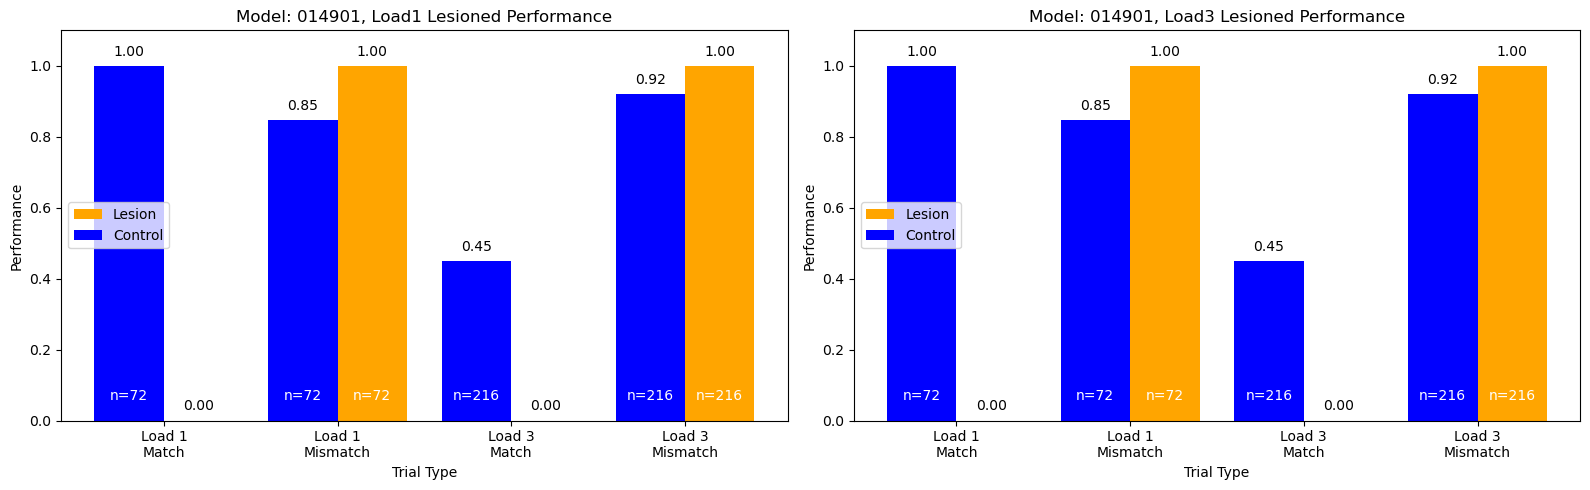

In [8]:
import matplotlib.gridspec as gridspec

condn_phrase = 'delay'
condn_num = 150

for model_name in model_names[:1]: # start with first 4 models for testing

    trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(
        model_name, condn_phrase, condn_num,
        other_labels='precomputed.',
        all_models_dir=all_models_dir
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for i, load_lesion in enumerate([1, 3]):
        other_labels = f'precomputed_lesion_all_inh_postsyn_half'
        trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(
            model_name, condn_phrase, condn_num,
            other_labels=other_labels,
            all_models_dir=all_models_dir
        )
        
        # compare performance of lesion vs control, split by load & match/mismatch
        perfs_lesion = []
        perfs_ctrl = []
        n_lesion_trials = []
        n_ctrl_trials = []
        x_labels = []
        for j, load in enumerate([1, 3]):
            for k, match in enumerate([1, -1]):  # 1 = match, -1 = mismatch
                lesion_trial_idxs = np.where((trial_labels[:, 0] == load) & (trial_labels[:, 1] == match))[0]
                perfs_lesion.append(np.mean(trial_perfs[lesion_trial_idxs]))
                n_lesion_trials.append(len(lesion_trial_idxs))
                ctrl_trial_idxs = np.where((trial_labels_ctrl[:, 0] == load) & (trial_labels_ctrl[:, 1] == match))[0]
                perfs_ctrl.append(np.mean(trial_perfs_ctrl[ctrl_trial_idxs]))
                n_ctrl_trials.append(len(ctrl_trial_idxs))
                x_labels.append(f"Load {load}\n{'Match' if match == 1 else 'Mismatch'}")
        axs[i].bar(np.arange(len(perfs_lesion))+0.2, perfs_lesion, width=0.4, color='orange', alpha=1, label='Lesion')
        axs[i].bar(np.arange(len(perfs_ctrl))-0.2, perfs_ctrl, width=0.4, color='blue', alpha=1, label='Control')
        # show n inside bars
        for j, (perf_lesion, perf_ctrl) in enumerate(zip(perfs_lesion, perfs_ctrl)):
            axs[i].text(j+0.2, perf_lesion + 0.02, f"{perf_lesion:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j-0.2, perf_ctrl + 0.02, f"{perf_ctrl:.2f}", ha='center', va='bottom', fontsize=10, color='black')
            axs[i].text(j+0.2, 0.05, f"n={n_lesion_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
            axs[i].text(j-0.2, 0.05, f"n={n_ctrl_trials[j]}", ha='center', va='bottom', fontsize=10, color='white')
        axs[i].set_ylabel("Performance")
        axs[i].set_xlabel("Trial Type")
        axs[i].set_xticks(np.arange(len(perfs_lesion)))
        axs[i].set_xticklabels(x_labels, rotation=0, ha='center')
        axs[i].set_ylim(0, 1.1)
        axs[i].legend()
        axs[i].set_title(f"Model: {model_name[-6:]}, Load{load_lesion} Lesioned Performance")
    
    plt.tight_layout()
    plt.show()

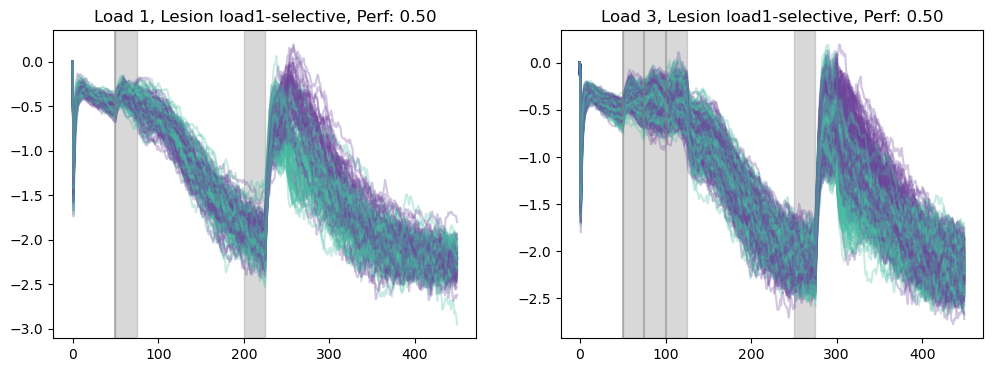

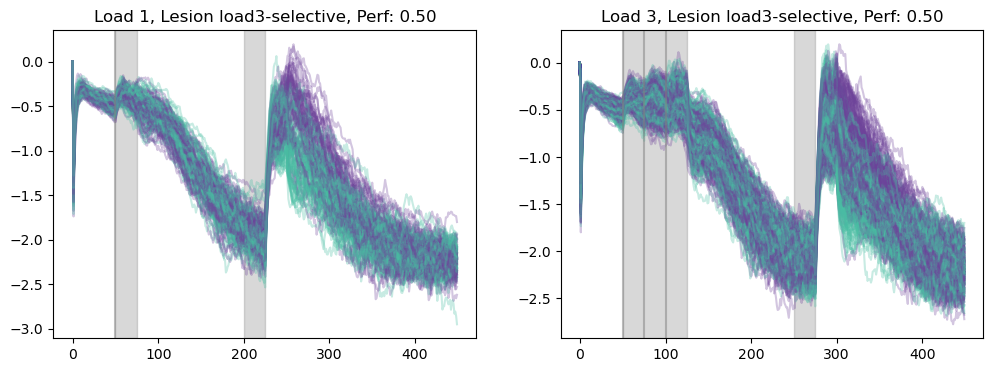

In [12]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

model_name = model_names[0]
    
for load_lesion in [1,3]: # 0, 1, 2, 3

    other_labels= 'precomputed_lesion_all_inh_postsyn_half'
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion load{load_lesion}-selective, Perf: {perf:.2f}")
        axs[i].axvspan(
            settings["stim_on"],
            settings["stim_on"] + load*settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.5)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

In [32]:
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 150,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}